<a href="https://colab.research.google.com/github/MOHAMMAD-Ghouse/Machine-Learning-on-Big-Data-Portfolio/blob/main/Week_10_Diabetes_Prediction_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark -q

import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler, Imputer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = (
    SparkSession.builder
    .appName("DiabetesPrediction")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.0.4


In [2]:
DATA_PATH = "/content/diabetes (1).csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

df.printSchema()
df.show(5)

Total Rows: 768
Total Columns: 9
root
 |-- Pregnancies: integer (nullable = true)
 |-- Glucose: integer (nullable = true)
 |-- BloodPressure: integer (nullable = true)
 |-- SkinThickness: integer (nullable = true)
 |-- Insulin: integer (nullable = true)
 |-- BMI: double (nullable = true)
 |-- DiabetesPedigreeFunction: double (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Outcome: integer (nullable = true)

+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|      0|
|          8|    183|           64|            0|      0|23.3|                

In [3]:
print("Statistical Summary:")
df.describe().show()

print("Outcome Distribution:")
df.groupBy("Outcome").count().orderBy("Outcome").show()

# Replace medically invalid zero values with null
health_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in health_columns:
    df = df.withColumn(
        column,
        F.when(F.col(column) == 0, None)
         .otherwise(F.col(column))
    )

# Fill missing values using median
imputer = Imputer(
    inputCols=health_columns,
    outputCols=[col + "_clean" for col in health_columns],
    strategy="median"
)

df_clean = imputer.fit(df).transform(df)

print("Data cleaning completed!")

Statistical Summary:
+-------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------------+------------------+------------------+
|summary|       Pregnancies|          Glucose|     BloodPressure|     SkinThickness|           Insulin|               BMI|DiabetesPedigreeFunction|               Age|           Outcome|
+-------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------------+------------------+------------------+
|  count|               768|              768|               768|               768|               768|               768|                     768|               768|               768|
|   mean|3.8450520833333335|     120.89453125|       69.10546875|20.536458333333332| 79.79947916666667|31.992578124999977|      0.4718763020833327|33.240885416666664|0.3489583333333333|
| stddev|  3.36957806269887|31.97261819513622|19.

In [4]:
feature_columns = [
    "Pregnancies",
    "Glucose_clean",
    "BloodPressure_clean",
    "SkinThickness_clean",
    "Insulin_clean",
    "BMI_clean",
    "DiabetesPedigreeFunction",
    "Age"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

data = assembler.transform(df_clean)

data = data.withColumn(
    "label",
    F.col("Outcome").cast("double")
)

data.select(
    "features",
    "label"
).show(5, truncate=False)

+-------------------------------------------+-----+
|features                                   |label|
+-------------------------------------------+-----+
|[6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0]|1.0  |
|[1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0] |0.0  |
|[8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0]|1.0  |
|[1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0]  |0.0  |
|[0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0]|1.0  |
+-------------------------------------------+-----+
only showing top 5 rows


In [5]:
train_data, test_data = data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())


# Logistic Regression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100
)

lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)


# Random Forest
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=8,
    seed=42
)

rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)


# Accuracy Evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

lr_accuracy = evaluator.evaluate(lr_predictions)
rf_accuracy = evaluator.evaluate(rf_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("Random Forest Accuracy:", round(rf_accuracy, 4))

Training Records: 645
Testing Records: 123
Logistic Regression Accuracy: 0.7967
Random Forest Accuracy: 0.7642


+-------------------+------------------+
|              Model|          Accuracy|
+-------------------+------------------+
|Logistic Regression|0.7967479674796748|
|      Random Forest|0.7642276422764228|
+-------------------+------------------+



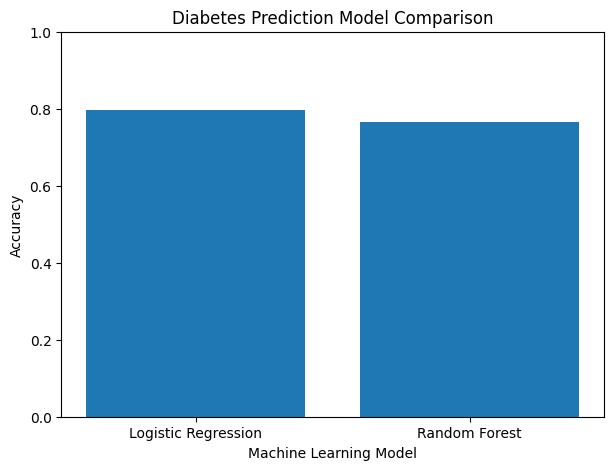


FINAL PROJECT — DIABETES PREDICTION USING PYSPARK

PROJECT COMPLETED SUCCESSFULLY

DATASET:
• 768 patient records
• 8 medical features
• Target: Diabetes Outcome

DATA PROCESSING:
• Spark DataFrames
• Statistical analysis
• Invalid zero-value handling
• Median imputation
• Feature vector creation

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

MODEL EVALUATION:
• Train/Test Split
• Accuracy comparison

CONCLUSION:
The diabetes dataset was processed using PySpark to
predict whether a patient is likely to have diabetes.
Data preprocessing was applied to handle invalid zero
values, followed by median imputation.

Two machine learning models were trained and compared
using classification accuracy.

FINAL PROJECT COMPLETE



In [6]:
results = [
    ("Logistic Regression", float(lr_accuracy)),
    ("Random Forest", float(rf_accuracy))
]

results_df = spark.createDataFrame(
    results,
    ["Model", "Accuracy"]
)

results_df.show()


# Model comparison graph
results_pd = results_df.toPandas()

plt.figure(figsize=(7, 5))

plt.bar(
    results_pd["Model"],
    results_pd["Accuracy"]
)

plt.title("Diabetes Prediction Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.show()


print("""
====================================================
FINAL PROJECT — DIABETES PREDICTION USING PYSPARK
====================================================

PROJECT COMPLETED SUCCESSFULLY

DATASET:
• 768 patient records
• 8 medical features
• Target: Diabetes Outcome

DATA PROCESSING:
• Spark DataFrames
• Statistical analysis
• Invalid zero-value handling
• Median imputation
• Feature vector creation

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

MODEL EVALUATION:
• Train/Test Split
• Accuracy comparison

CONCLUSION:
The diabetes dataset was processed using PySpark to
predict whether a patient is likely to have diabetes.
Data preprocessing was applied to handle invalid zero
values, followed by median imputation.

Two machine learning models were trained and compared
using classification accuracy.

====================================================
FINAL PROJECT COMPLETE
====================================================
""")